In [1]:
from gensim.models import Word2Vec

#word2vec_model = Word2Vec.load("./unlabelled/10_epoch_embeddings_long_sentences.model")
word2vec_model = Word2Vec.load("./unlabelled/character_embeddings_6epoch.model")

ModuleNotFoundError: No module named 'gensim'

In [1]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

model_name = 'jbochi/madlad400-3b-mt'
model = T5ForConditionalGeneration.from_pretrained(model_name, device_map=None)
tokenizer = T5Tokenizer.from_pretrained(model_name)


/home/andreas/miniconda3/envs/nlp/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: libtorch_cpu.so: cannot enable executable stack as shared object requires: Invalid argument

In [3]:
sentence = "".join("假設 A 同 B 之間 有 座 好 高 嘅 山 ， 噉 就要 諗 吓 ， 條 路 應該 跨過 座 山 吖 ， 穿過 座 山 吖 ， 定係 直接 兜 過 座 山 呢 ？".split(" "))
print(len(tokenizer(sentence)["input_ids"]))
print(len(sentence))

52
46


In [4]:
ts = []
for t in tokenizer(sentence)["input_ids"]:
    ts.append(tokenizer.decode(t))
    print(str(t) + " - " + tokenizer.decode(t))

print(" ".join(ts))

805 - 
38597 - 假
25268 - 設
1026 - A
5836 - 同
1451 - B
5088 - 之
13561 - 間
1993 - 有
22569 - 座
5123 - 好
4421 - 高
250846 - 嘅
8418 - 山
1088 - ，
778 - �
702 - �
686 - �
5350 - 就
4394 - 要
781 - �
720 - �
700 - �
248891 - 吓
1088 - ，
57771 - 條
8981 - 路
25491 - 應
37759 - 該
127012 - 跨
8682 - 過
22569 - 座
8418 - 山
255251 - 吖
1088 - ，
67892 - 穿
8682 - 過
22569 - 座
8418 - 山
255251 - 吖
1088 - ，
4750 - 定
73348 - 係
10351 - 直
9516 - 接
249118 - 兜
8682 - 過
22569 - 座
8418 - 山
37101 - 呢
8370 - ？
2 - </s>
 假 設 A 同 B 之 間 有 座 好 高 嘅 山 ， � � � 就 要 � � � 吓 ， 條 路 應 該 跨 過 座 山 吖 ， 穿 過 座 山 吖 ， 定 係 直 接 兜 過 座 山 呢 ？ </s>


In [5]:
import torch

In [6]:

text = "<2en> 羅漢係我兄弟，他成日在正午放風箏，就算天陰陰。"
input_ids = tokenizer(text, return_tensors="pt").input_ids

In [7]:
madlad_embeddings = torch.load("madlad_embedding.pth")

In [8]:

def get_madlad_embedding_layer():
    return madlad_embeddings # decoder and encoder uses the same embedding weights
get_madlad_embedding_layer()["weight"].dtype

torch.float32

In [9]:
def get_madlad_embedding(token: str, include_start_and_end_tokens=False) -> torch.Tensor:
    '''
    [:, -1, :] is the EOF token embedding
    '''
    input_ids = tokenizer(token, return_tensors="pt").input_ids
    
    if not include_start_and_end_tokens:
        input_ids = input_ids[input_ids != 2]
        input_ids = input_ids[input_ids != 805]
    
    embeddings = get_madlad_embedding_layer()["weight"][input_ids]
    
    return embeddings


start_token = (get_madlad_embedding(''))
embedding = get_madlad_embedding('<2en>')

embedding.shape, start_token.shape

(torch.Size([1, 1024]), torch.Size([0, 1024]))

In [10]:
from torch import nn
import numpy as np
import datasets
from datasets import DatasetDict
gatitos: DatasetDict = datasets.load_dataset("google/smol", "gatitos__yue_zh") # type: ignore

In [21]:
token_translations: list[dict[str, list[str]]] = []
for i in range(gatitos['train']['src'].__len__()): 
    for s in gatitos['train']['src'][i].split('; '):
        if np.all([x in word2vec_model.wv for x in s]):
            for t in gatitos['train']['trgs'][i]:
                token_translations.append({
                    'src': s,
                    'trg': t
                })

In [25]:
len(token_translations)

5138

In [26]:
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(token_translations, train_size=0.9, shuffle=True)

In [131]:
token_translations[40]

{'src': '請', 'trg': '请'}

In [149]:
i = 40
print(torch.norm(mean_embedding(madlad_tokenize(token_translations[i]["src"]), word2vec_model)))
print(torch.norm(mean_embedding(madlad_tokenize(token_translations[i]["src"]), word2vec_model) @ W.cpu()))
print(torch.norm(get_madlad_embedding(token_translations[i]["trg"])))

tensor(3.8519)
tensor(205.4378, grad_fn=<LinalgVectorNormBackward0>)
tensor(331.2567)


In [30]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [31]:
device

'cuda'

In [164]:
epochs = 20
lr = 10**-2
train_losses=[]
test_losses=[]

from tqdm.notebook import tqdm

W = torch.randn(1024, 1024, requires_grad=True, device=device)
#W = torch.eye(1024, requires_grad=True, device=device)
optim = torch.optim.Adam([W], lr=lr)
#criterion = nn.MSELoss()
batchsize = 64


In [165]:
def criterion(X, W, Y): 
    pred = X @ W
    targets = Y
    diff = torch.norm(pred - targets,dim=1)
    loss = diff @ diff

    return loss


In [61]:
def mean_embedding(chars, model):
    return torch.mean(torch.tensor([model.wv[char] for char in chars]), dim=0)

In [108]:
def madlad_tokenize(word):
    return [tokenizer.decode(x) for x in tokenizer(word)["input_ids"] if x != 2 and x != 805]

In [60]:
torch.mean(torch.tensor([word2vec_model.wv[char] for char in madlad_tokenize(train_data[0]["src"])]),dim=0).shape

torch.Size([1024])

In [102]:
get_madlad_embedding(token_translations[0]["trg"])

tensor([[ 18.2741,  12.1553, -24.5976,  ...,  -3.7271,   2.0311,   6.8557],
        [  6.2296,  11.2902,  -4.9938,  ...,  -4.9569,  -3.9063,   1.5804],
        [ 10.7053,  18.4885,  -7.5104,  ..., -19.4815,  -7.9691,   9.9006]])

In [109]:
madlad_tokenize(token_translations[0]["trg"])

['广', '州', '话']

In [110]:
mean_embedding(madlad_tokenize(token_translations[i]["trg"]), word2vec_model) @ W.cpu()

tensor([-0.3736, -1.1263, -4.0728,  ...,  6.1410,  2.4158, -3.3334],
       grad_fn=<SqueezeBackward4>)

In [168]:
epochs = 5

In [170]:
for epoch in tqdm(range(epochs)):
    epoch_loss = 0
    j = 0
    for i in range(0, len(train_data)-batchsize, batchsize):
        #existing_indices = [x for x in range(i, min(i+batchsize, len(train_data))) if train_data[x]["trg"] in word2vec_model.wv]
        #print(len(existing_indices))
        #print(existing_indices)
        #if train_data[i]["trg"] in word2vec_model.wv:
        mandarin_embeddings = torch.stack([torch.mean(get_madlad_embedding(train_data[x]['trg']),dim=0) for x in range(i, i+batchsize)]).to(device)
        cantonese_embeddings = torch.stack([mean_embedding(madlad_tokenize(train_data[x]["src"]), word2vec_model) for x in range(i,i+batchsize)]).to(device)
        
        optim.zero_grad()
        loss = criterion(cantonese_embeddings, W, mandarin_embeddings)

        loss.backward()
        optim.step()
        epoch_loss += loss.item() 
        j = j + batchsize
    epoch_loss = epoch_loss / j

    if epoch % 1 == 0:
        test_loss = 0
        j = 0
        for i in range(0, len(test_data)-batchsize, batchsize):
            #existing_indices = [x for x in range(i, min(i+batchsize, len(test_data))) if test_data[x]["trg"] in word2vec_model.wv]
            mandarin_embeddings = torch.stack([torch.mean(get_madlad_embedding(test_data[x]['trg']),dim=0) for x in range(i,i+batchsize)]).to(device)
            cantonese_embeddings = torch.stack([mean_embedding(madlad_tokenize(test_data[x]["src"]), word2vec_model) for x in range(i,i+batchsize)]).to(device)

            test_loss += criterion(cantonese_embeddings, W, mandarin_embeddings).detach().cpu() 
            j = j + batchsize

        test_loss = test_loss / j
        print(f"{epoch:3d}: train loss: {epoch_loss:.5f}, test loss: {test_loss:.5f}")
        train_losses.append(epoch_loss)
        test_losses.append(test_loss)

            

  0%|          | 0/5 [00:00<?, ?it/s]

  0: train loss: 42648.08474, test loss: 60532.42188
  1: train loss: 42329.36789, test loss: 60490.47656
  2: train loss: 42029.61344, test loss: 60456.98047
  3: train loss: 41747.20166, test loss: 60431.04688
  4: train loss: 41480.69450, test loss: 60411.92969


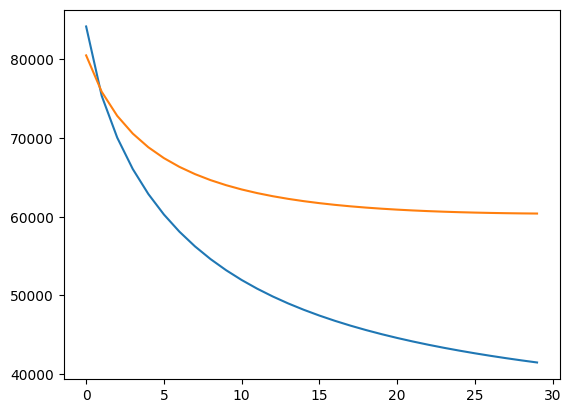

In [171]:
import matplotlib.pyplot as plt
plt.plot(train_losses)
plt.plot(test_losses)

In [172]:
W

tensor([[ 0.9513, -1.3609, -0.0291,  ..., -0.3664,  0.1804, -1.8858],
        [ 1.1169, -2.0045, -1.2542,  ...,  0.5811, -2.6845, -0.3105],
        [ 1.5446, -4.9577,  0.4201,  ...,  2.8762, -2.4297,  4.1220],
        ...,
        [-0.5830, -4.1616, -0.1931,  ...,  1.5472, -1.3759, -2.8688],
        [-2.8024,  2.1288, -1.1085,  ..., -0.9120, -1.3031, -1.6955],
        [ 0.3897, -1.1401,  1.3886,  ..., -0.4244,  0.3417,  1.9467]],
       device='cuda:0', requires_grad=True)

In [173]:
import numpy as np
with open('transformation_matrix_3.npy' , "wb") as f:
    np.save(f, W.detach().cpu().numpy())

In [53]:
with open('transformation_matrix.npy', 'rb') as f:
    transformation_matrix = np.load(f)

In [35]:
embeds_ = get_madlad_embedding("<2en> 你好", include_start_and_end_tokens=True)

In [15]:
generated = model.generate(inputs_embeds=embeds_)

In [16]:
tokenizer.decode(generated[0], skip_special_tokens=True)

'Hello.'

In [36]:
translation_token = get_madlad_embedding("<2en>")
text = "羅漢係我兄弟，他成日在正午放風箏，就算天陰陰"

for t in tokenizer('\b<2en>')['input_ids']:
    print(tokenizer.decode(t), t)

 805
 58531
<2en> 38
</s> 2


In [58]:
t = 10900
print(torch.norm(torch.tensor(transformation_matrix @ word2vec_model.wv[tokenizer.decode(t)]).unsqueeze(0)))
print(torch.norm(get_madlad_embedding_layer(1)))

tensor(6.5708)
tensor(207970.9688)


In [59]:
torch.norm(get_madlad_embedding(tokenizer.decode(t)))

tensor(339.8831)

In [100]:
text = "<2en>羅漢係我兄弟，他成日在正午放風箏，就算天陰陰"
#translation_token = get_madlad_embedding(text)

token_embeddings = []
for t in tokenizer(text)['input_ids']:
    #print(t)
    if tokenizer.decode(t) in word2vec_model.wv:
        #print(1)
        token_embedding = torch.tensor(word2vec_model.wv[tokenizer.decode(t)] @ transformation_matrix).unsqueeze(0)
    else:
        #print(2)
        token_embedding = get_madlad_embedding_layer(1)[t].unsqueeze(0)
        
    token_embeddings.append(torch.Tensor(token_embedding))
print(token_embeddings)
token_embeddings = torch.tensor(np.array([x.detach().cpu().numpy() for x in token_embeddings]))#.permute(1,0,2)

[tensor([[ 0.1655,  1.1890, -2.1539,  ..., -4.0582,  1.0744, -0.5774]]), tensor([[-3.9575e+00,  2.3815e-03,  1.6395e+00,  ...,  2.5391e+00,
         -1.6154e+01, -5.2441e+00]]), tensor([[ 0.2786, -0.0220, -0.2956,  ..., -0.1643,  0.1462, -0.2801]]), tensor([[ 0.1411, -0.1823, -0.4221,  ..., -0.0942,  0.1932,  0.0847]]), tensor([[-1.3523e-04, -2.0581e-01, -7.3519e-02,  ..., -1.6404e-01,
         -8.0244e-02,  3.9192e-02]]), tensor([[-0.0552, -0.0078,  0.1035,  ..., -0.0029,  0.0019,  0.0370]]), tensor([[-0.1698,  0.1402, -0.0519,  ..., -0.0746, -0.0947,  0.0488]]), tensor([[-0.1934, -0.1819,  0.1868,  ...,  0.1987, -0.0473, -0.4379]]), tensor([[-0.1313, -0.1198, -0.0662,  ..., -0.1960, -0.0077,  0.0999]]), tensor([[-0.4631, -0.0986, -0.2124,  ..., -0.1580, -0.2502, -0.2745]]), tensor([[ 0.1835,  0.0653,  0.0169,  ..., -0.1912, -0.0066,  0.0437]]), tensor([[ 0.3518,  0.0394, -0.0723,  ..., -0.3567, -0.1769,  0.0550]]), tensor([[-0.1107,  0.0798, -0.0971,  ...,  0.0352, -0.0668, -0.1245]]

In [101]:
token_embeddings.shape

torch.Size([25, 1, 1024])

In [102]:
token_embeddings

tensor([[[ 1.6555e-01,  1.1890e+00, -2.1539e+00,  ..., -4.0582e+00,
           1.0744e+00, -5.7736e-01]],

        [[-3.9575e+00,  2.3815e-03,  1.6395e+00,  ...,  2.5391e+00,
          -1.6154e+01, -5.2441e+00]],

        [[ 2.7861e-01, -2.2004e-02, -2.9561e-01,  ..., -1.6434e-01,
           1.4615e-01, -2.8010e-01]],

        ...,

        [[-3.7018e-01, -3.6549e-01, -2.5582e-01,  ..., -1.8197e-01,
           1.7310e-01, -3.3045e-02]],

        [[-3.7018e-01, -3.6549e-01, -2.5582e-01,  ..., -1.8197e-01,
           1.7310e-01, -3.3045e-02]],

        [[ 8.8776e-02,  7.7090e-01, -1.2226e+00,  ...,  6.7889e-01,
           8.6144e-01, -4.7935e-01]]])

In [159]:
model.encoder.embed_tokens(tokenizer(text,  return_tensors="pt").input_ids).shape

torch.Size([1, 25, 1024])

In [173]:
torch.all(token_embeddings == model.encoder.embed_tokens(tokenizer(text,  return_tensors="pt").input_ids))

tensor(True)

In [160]:
token_embeddings == model.encoder.embed_tokens(tokenizer(text,  return_tensors="pt").input_ids)

False

In [40]:
torch.tensor(np.array([x.detach().cpu().numpy() for x in token_embeddings]))

NameError: name 'token_embeddings' is not defined

In [102]:
model.encoder.embed_tokens(tokenizer(text,  return_tensors="pt").input_ids)

tensor([[[ 1.6555e-01,  1.1890e+00, -2.1539e+00,  ..., -4.0582e+00,
           1.0744e+00, -5.7736e-01],
         [-3.9575e+00,  2.3815e-03,  1.6395e+00,  ...,  2.5391e+00,
          -1.6154e+01, -5.2441e+00],
         [ 1.5735e+01,  1.1179e+01,  5.3661e+00,  ...,  8.9747e+00,
          -1.1488e+01, -1.1491e+01],
         ...,
         [ 2.3343e+00,  3.2717e+01,  7.6224e+00,  ...,  2.3185e+00,
          -1.1847e+01, -1.5596e+00],
         [ 2.3343e+00,  3.2717e+01,  7.6224e+00,  ...,  2.3185e+00,
          -1.1847e+01, -1.5596e+00],
         [ 8.8776e-02,  7.7090e-01, -1.2226e+00,  ...,  6.7889e-01,
           8.6144e-01, -4.7935e-01]]], grad_fn=<EmbeddingBackward0>)

In [68]:
torch.tensor(token_embeddings)

ValueError: only one element tensors can be converted to Python scalars

In [54]:
torch.stack(token_embeddings).shape

torch.Size([25, 1, 1024])

In [58]:
torch.mean(torch.stack(token_embeddings), dim=0).shape

torch.Size([1, 1024])

In [59]:
output = model.generate(inputs_embeds=torch.mean(torch.stack(token_embeddings).unsqueeze(0), dim=0))

In [182]:
out = model.generate(inputs_embeds=token_embeddings)
tokenizer.decode(out[0], skip_special_tokens=True)

'I i k ets tn y k s y y t a t y y'

In [106]:
true_embeds = model.encoder.embed_tokens(tokenizer(text,return_tensors="pt").input_ids)

In [ ]:
true_embeds = model.encoder.embed_tokens(tokenizer(text,return_tensors="pt").input_ids)
z = model.generate(inputs_embeds=true_embeds)
tokenizer.decode(z[0], skip_special_tokens=True)

'Rohan is my brother, he flies kites at noon every day, even in the dark'

In [85]:
tokenizer.decode(out[0], skip_special_tokens=True)

'Rohan is my brother, he is a rocket, he is a rocket, he is'

In [81]:
z = model.generate(tokenizer(text, return_tensors="pt").input_ids.to(model.device))
tokenizer.decode(z[0], skip_special_tokens=True)

'Rohan is my brother, he flies kites at noon every day, even in the dark'